**CELL 1 — Install Detectron2 + Roboflow**

In [ ]:
!python -m pip install -q 'git+https://github.com/facebookresearch/detectron2.git'
!pip install -q roboflow


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.4/86.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 127.5 MB/s eta 0:00:00


**CELL 2 — Imports**

In [ ]:
import os, json, random, copy
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

from roboflow import Roboflow

from detectron2.utils.logger import setup_logger
setup_logger()

from detectron2 import model_zoo
from detectron2.config import get_cfg
from detectron2.engine import DefaultTrainer, DefaultPredictor
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.data.datasets import register_coco_instances
from detectron2.utils.visualizer import Visualizer

from detectron2.data import detection_utils as utils
import detectron2.data.transforms as T
from detectron2.data import build_detection_train_loader, build_detection_test_loader

from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.structures import Boxes, pairwise_iou
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


**CELL 3 — Download Roboflow COCO dataset + Register vào Detectron2**

In [ ]:
import os
rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])
project = rf.workspace("fire-detection-lfqdr").project("wildfire_satelite-klbbn")
version = project.version(4)
dataset = version.download("coco")

data_path = dataset.location
print("Dataset path:", data_path)

def fix_coco_json_to_single_fire(split):
    jf = os.path.join(data_path, split, "_annotations.coco.json")
    with open(jf, "r") as f:
        coco = json.load(f)

    # tạo category mới duy nhất
    new_cats = [{"id": 1, "name": "fire"}]
    coco["categories"] = new_cats

    # remap tất cả ann về category_id=1 (COCO chuẩn)
    for ann in coco.get("annotations", []):
        ann["category_id"] = 1

    with open(jf, "w") as f:
        json.dump(coco, f)

for split in ["train", "valid", "test"]:
    fix_coco_json_to_single_fire(split)

print("Fixed COCO JSON: only one class 'fire'")

def load_coco_classes_unique(json_file):
    import json
    with open(json_file, "r") as f:
        coco = json.load(f)
    cats = coco.get("categories", [])
    # sort theo id rồi unique theo name
    cats = sorted(cats, key=lambda x: x["id"])
    names = []
    for c in cats:
        if c["name"] not in names:
            names.append(c["name"])
    return names


for d in ["train", "valid", "test"]:
    json_file = os.path.join(data_path, d, "_annotations.coco.json")
    img_dir   = os.path.join(data_path, d)
    register_name = f"forest_fire_{d}"

    # tránh register trùng tên khi chạy lại cell
    if register_name not in DatasetCatalog.list():
        register_coco_instances(register_name, {}, json_file, img_dir)

    # set thing_classes để không bị lỗi AttributeError
    MetadataCatalog.get(register_name).thing_classes = load_coco_classes_unique(json_file)

forest_metadata = MetadataCatalog.get("forest_fire_train")
print("Registered datasets:", [x for x in DatasetCatalog.list() if x.startswith("forest_fire_")])
print("Classes:", forest_metadata.thing_classes)

train_dicts = DatasetCatalog.get("forest_fire_train")
valid_dicts = DatasetCatalog.get("forest_fire_valid")
test_dicts  = DatasetCatalog.get("forest_fire_test")

print("Train images:", len(train_dicts))
print("Valid images:", len(valid_dicts))
print("Test images :", len(test_dicts))

**CELL 4 — Custom mapper**

In [ ]:
def custom_mapper(dataset_dict):
    dataset_dict = copy.deepcopy(dataset_dict)
    image = utils.read_image(dataset_dict["file_name"], format="BGR")

    # === PREPROCESS: resize cố định 640x640 ===
    transform_list = [
        T.Resize((640, 640))

    ]

    image, transforms = T.apply_transform_gens(transform_list, image)
    dataset_dict["image"] = torch.as_tensor(image.transpose(2, 0, 1).astype("float32"))

    annos = [
        utils.transform_instance_annotations(obj, transforms, image.shape[:2])
        for obj in dataset_dict.pop("annotations")
        if obj.get("iscrowd", 0) == 0
    ]
    instances = utils.annotations_to_instances(annos, image.shape[:2])
    dataset_dict["instances"] = utils.filter_empty_instances(instances)
    return dataset_dict


**CELL 5 — Trainer dùng mapper**

In [ ]:
class SimpleTrainer(DefaultTrainer):
    @classmethod
    def build_train_loader(cls, cfg):
        return build_detection_train_loader(cfg, mapper=custom_mapper)



**CELL 6 — Config train**

In [ ]:
class CocoTrainer(DefaultTrainer):
    @classmethod
    def build_evaluator(cls, cfg, dataset_name, output_folder=None):
        if output_folder is None:
            output_folder = os.path.join(cfg.OUTPUT_DIR, "inference")

        return COCOEvaluator(dataset_name, cfg, True, output_folder)
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")
cfg.DATASETS.TRAIN = ("forest_fire_train",)
cfg.DATASETS.TEST  = ("forest_fire_valid",)   # bật valid để theo dõi mAP
cfg.DATALOADER.NUM_WORKERS = 2

cfg.MODEL.DEVICE = "cuda"
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")
cfg.MODEL.WEIGHTS = path_to_old_model
num_classes = len(MetadataCatalog.get("forest_fire_train").thing_classes)
cfg.MODEL.ROI_HEADS.NUM_CLASSES = num_classes
print("NUM_CLASSES =", num_classes)

# batch
cfg.SOLVER.IMS_PER_BATCH = 16

# tính iters/epoch
import math
train_images = len(DatasetCatalog.get("forest_fire_train"))
iters_per_epoch = math.ceil(train_images / cfg.SOLVER.IMS_PER_BATCH)
print("Iters per epoch:", iters_per_epoch)

# ====== SOLVER (quan trọng) ======
cfg.SOLVER.BASE_LR = 0.0025
cfg.SOLVER.WARMUP_ITERS = 0
cfg.SOLVER.MAX_ITER = iters_per_epoch * 20
cfg.SOLVER.STEPS = (int(cfg.SOLVER.MAX_ITER*0.6), int(cfg.SOLVER.MAX_ITER*0.85))
cfg.SOLVER.GAMMA = 0.1

# eval mỗi epoch
cfg.TEST.EVAL_PERIOD = 500
cfg.SOLVER.CHECKPOINT_PERIOD = iters_per_epoch
# Lưu checkpoint mỗi 500 bước luôn (để lỡ thấy ngon thì lấy luôn)
cfg.SOLVER.CHECKPOINT_PERIOD = 500

# Output vào Drive
cfg.OUTPUT_DIR = "/content/drive/MyDrive/Training_FasterRCNN_Fire_Eval500"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
# cfg.OUTPUT_DIR = "./output_fire_faster-rcnn_640"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

# nếu muốn train lại từ đầu:
# cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")


NUM_CLASSES = 1
[12/19 08:23:29 d2.data.datasets.coco]: Loaded 8272 images in COCO format from /content/wildfire_satelite-4/train/_annotations.coco.json
Iters per epoch: 2068


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**CELL 7 — Train**

In [ ]:
print("🚀tart training...")
trainer = CocoTrainer(cfg) # Dùng class CocoTrainer vừa tạo ở trên
trainer.resume_or_load(resume=True)
trainer.train()
print("Train finished!")


🚀 Start training...
[12/19 08:23:33 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        

**CELL 8 — Predictor**

In [ ]:
from detectron2.engine import DefaultPredictor
import os

# 1. Clone config
cfg_eval = cfg.clone()

# 2. TRỎ VÀO FILE 13958 (File này an toàn nhất)
# Hãy chắc chắn đường dẫn đúng, kiểm tra xem file có nằm ở đó không
weights_path = "/content/model_0005169.pth"

if not os.path.exists(weights_path):
    print(f"CHẾT DỞ! Không tìm thấy file: {weights_path}")
    print("Kiểm tra lại xem đã upload file model_0013958.pth lên chưa!")
else:
    cfg_eval.MODEL.WEIGHTS = weights_path

    # 3. SỬA LẠI THRESHOLD CHO FASTER R-CNN (Quan trọng)
    cfg_eval.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # Đặt 0.5 cho chuẩn

    # 4. Set dataset test
    cfg_eval.DATASETS.TEST = ("forest_fire_test",)

    # 5. Khởi tạo
    try:
        predictor = DefaultPredictor(cfg_eval)
        print("KHỞI TẠO THÀNH CÔNG! Model đã sẵn sàng.")
    except Exception as e:
        print("VẪN LỖI FILE HỎNG RỒI:")
        print(e)

**CELL 9 — COCO mAP**

In [ ]:
print("COCO Eval on test...")
evaluator = COCOEvaluator("forest_fire_test", output_dir=cfg_eval.OUTPUT_DIR)
test_loader = build_detection_test_loader(cfg_eval, "forest_fire_test")
results = inference_on_dataset(predictor.model, test_loader, evaluator)
results


🚀 COCO Eval on test...
[12/19 05:22:18 d2.data.datasets.coco]: Loaded 1104 images in COCO format from /content/wildfire_satelite-4/test/_annotations.coco.json
[12/19 05:22:18 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[12/19 05:22:18 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[12/19 05:22:18 d2.data.common]: Serializing 1104 elements to byte tensors and concatenating them all ...
[12/19 05:22:18 d2.data.common]: Serialized dataset takes 0.35 MiB
[12/19 05:22:18 d2.evaluation.evaluator]: Start inference on 1104 batches
[12/19 05:22:20 d2.evaluation.evaluator]: Inference done 11/1104. Dataloading: 0.0021 s/iter. Inference: 0.0936 s/iter. Eval: 0.0003 s/iter. Total: 0.0960 s/iter. ETA=0:01:44
[12/19 05:22:25 d2.evaluation.evaluator]: Inference done 67/1104. Dataloading: 0.0020 s/iter. Inference: 0.0884 s/iter. Ev

OrderedDict([('bbox',
              {'AP': 19.825109112404824,
               'AP50': 37.701189191149545,
               'AP75': 18.707604022119813,
               'APs': 5.115017097248022,
               'APm': 13.272024615676525,
               'APl': 31.375926457859805})])

**CELL 10 — Confusion matrix + Precision/Recall**

[12/19 05:08:10 d2.data.datasets.coco]: Loaded 1104 images in COCO format from /content/wildfire_satelite-4/test/_annotations.coco.json
🔄 Scanning 1104 images...

===== REPORT =====
TP, FP, FN: 1075 1415 888
Precision: 0.4317
Recall   : 0.5476
Miss : 0.4524
Accuracy : 0.3182


<Figure size 700x600 with 0 Axes>

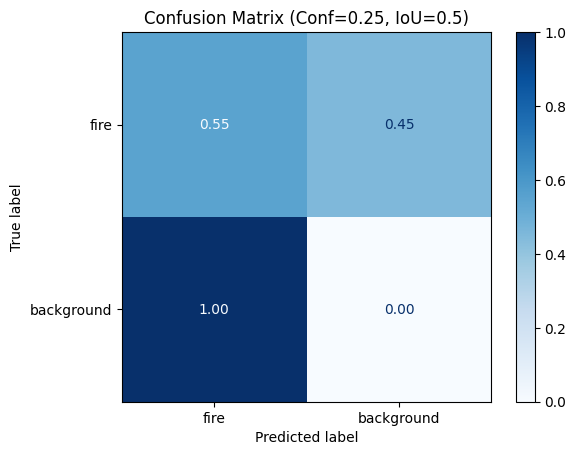

In [ ]:
CONFIDENCE_THRESHOLD = 0.25
IOU_THRESHOLD = 0.5

def coco_xywh_to_xyxy(box):
    x, y, w, h = box
    return [x, y, x + w, y + h]

def calculate_metrics_and_cm(predictor, dataset_name, conf_th, iou_th):
    dataset_dicts = DatasetCatalog.get(dataset_name)
    y_true, y_pred = [], []
    TP = FP = FN = 0

    print(f"🔄 Scanning {len(dataset_dicts)} images...")

    for d in dataset_dicts:
        img = cv2.imread(d["file_name"])
        outputs = predictor(img)

        inst = outputs["instances"].to("cpu")
        inst = inst[inst.scores >= conf_th]
        pred_boxes = inst.pred_boxes

        # GT: COCO bbox = XYWH => convert sang XYXY
        gt_xyxy = [coco_xywh_to_xyxy(ann["bbox"]) for ann in d.get("annotations", [])]
        gt_boxes = Boxes(torch.tensor(gt_xyxy, dtype=torch.float32)) if len(gt_xyxy) else Boxes(torch.zeros((0,4)))

        if len(gt_boxes) == 0:
            if len(pred_boxes) > 0:
                for _ in range(len(pred_boxes)):
                    y_true.append("background")
                    y_pred.append("fire")
                    FP += 1
            continue

        if len(pred_boxes) == 0:
            for _ in range(len(gt_boxes)):
                y_true.append("fire")
                y_pred.append("background")
            FN += len(gt_boxes)
            continue

        iou_matrix = pairwise_iou(pred_boxes, gt_boxes)
        matched_gt = set()

        for i in range(len(pred_boxes)):
            max_iou, max_idx = iou_matrix[i].max(dim=0)
            max_idx = int(max_idx.item())

            if float(max_iou) >= iou_th and max_idx not in matched_gt:
                y_true.append("fire")
                y_pred.append("fire")
                TP += 1
                matched_gt.add(max_idx)
            else:
                y_true.append("background")
                y_pred.append("fire")
                FP += 1

        missed = len(gt_boxes) - len(matched_gt)
        for _ in range(missed):
            y_true.append("fire")
            y_pred.append("background")
        FN += missed

    return TP, FP, FN, y_true, y_pred

TP, FP, FN, y_true_cm, y_pred_cm = calculate_metrics_and_cm(
    predictor, "forest_fire_test", CONFIDENCE_THRESHOLD, IOU_THRESHOLD
)

precision = TP / (TP + FP) if (TP + FP) else 0
recall    = TP / (TP + FN) if (TP + FN) else 0
accuracy  = TP / (TP + FP + FN) if (TP + FP + FN) else 0
missrate  = FN / (TP + FN) if (TP + FN) else 0

print("\n===== REPORT =====")
print("TP, FP, FN:", TP, FP, FN)
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"Miss : {missrate:.4f}")
print(f"Accuracy : {accuracy:.4f}")

labels = ["fire", "background"]
cm = confusion_matrix(y_true_cm, y_pred_cm, labels=labels, normalize='true')

plt.figure(figsize=(7,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format=".2f", cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix (Conf={CONFIDENCE_THRESHOLD}, IoU={IOU_THRESHOLD})")
plt.show()


**CELL 11 — Vẽ loss curve (metrics.json)**

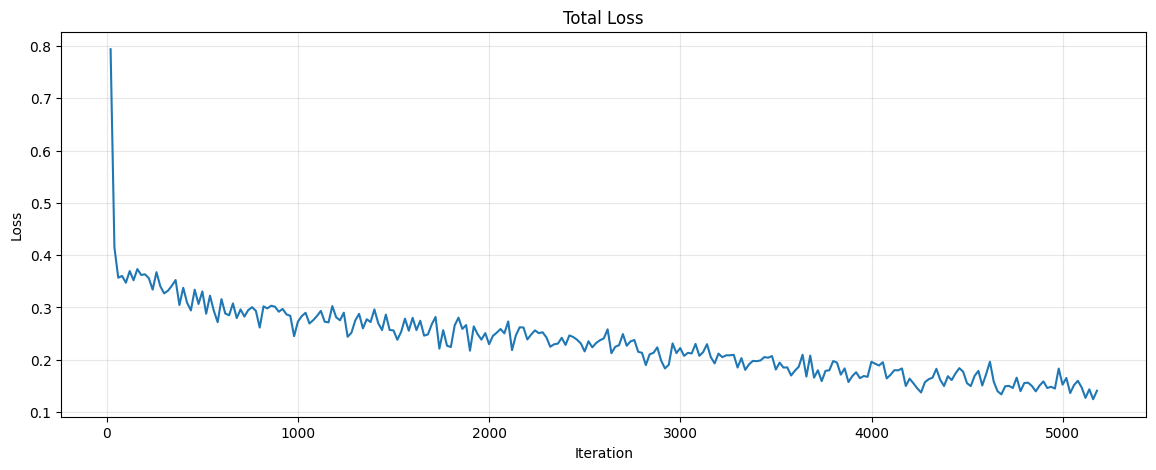

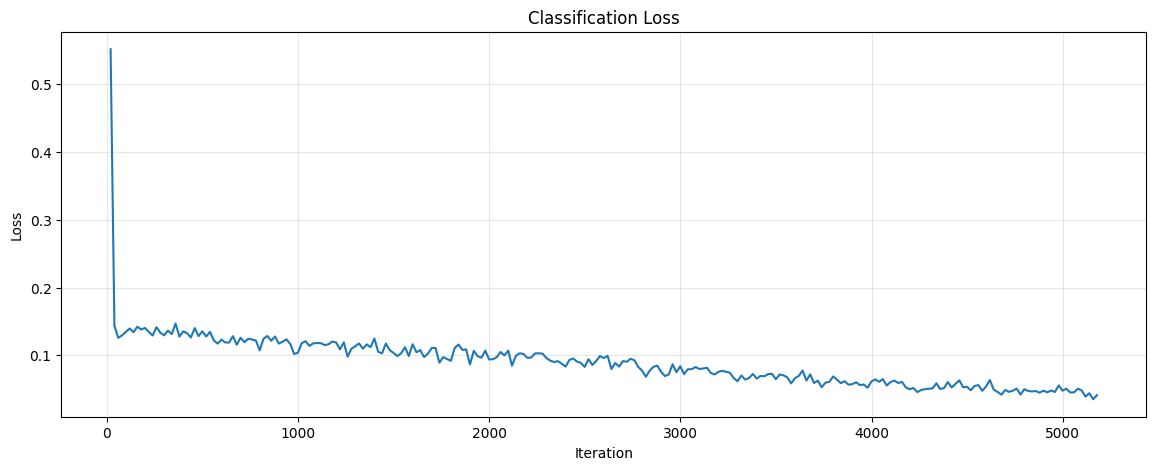

In [ ]:
def load_json_arr(json_path):
    arr = []
    with open(json_path, "r") as f:
        for line in f:
            arr.append(json.loads(line))
    return arr

metrics_path = "/content/metrics(2).json"
metrics = load_json_arr(metrics_path)

iters = [x["iteration"] for x in metrics if "total_loss" in x]
loss  = [x["total_loss"] for x in metrics if "total_loss" in x]
cls_l = [x.get("loss_cls", None) for x in metrics if "loss_cls" in x]

plt.figure(figsize=(14,5))
plt.plot(iters, loss)
plt.title("Total Loss")
plt.xlabel("Iteration"); plt.ylabel("Loss"); plt.grid(True, alpha=0.3)
plt.show()

if len([x for x in cls_l if x is not None]) > 0:
    iters2 = [x["iteration"] for x in metrics if "loss_cls" in x]
    cls2   = [x["loss_cls"] for x in metrics if "loss_cls" in x]
    plt.figure(figsize=(14,5))
    plt.plot(iters2, cls2)
    plt.title("Classification Loss")
    plt.xlabel("Iteration"); plt.ylabel("Loss"); plt.grid(True, alpha=0.3)
    plt.show()


**CELL 12 — Visualize vài ảnh test**

[12/19 05:14:42 d2.data.datasets.coco]: Loaded 1104 images in COCO format from /content/wildfire_satelite-4/test/_annotations.coco.json
Image: /content/wildfire_satelite-4/test/cl6cg8f7k00ail455g5xjf4zo_4_FALSE_COLOR__URBAN_jpg.rf.22152b5477f271048f017dcc4c727605.jpg
Scores: [0.9996915]


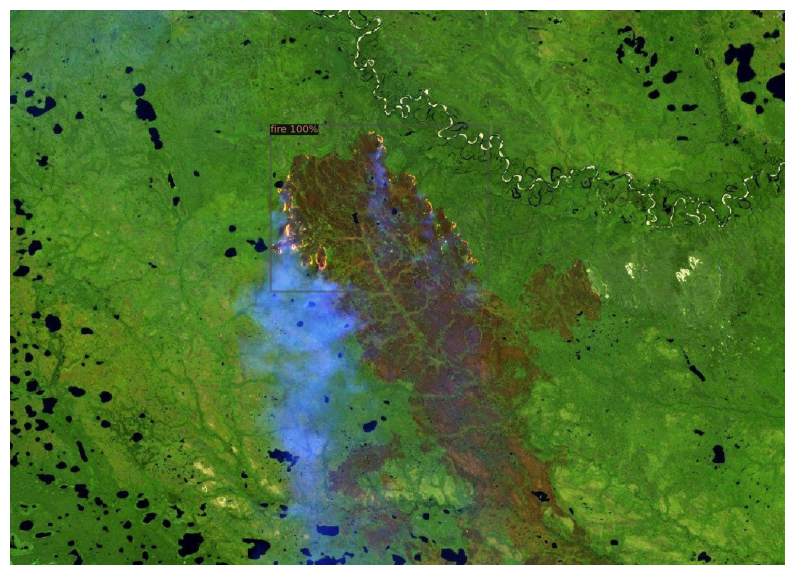

Image: /content/wildfire_satelite-4/test/cl6dyeg510004hg554xxs8aux_6_SWIR_jpg.rf.0a2a6d33d9c116d963de2900face32bb.jpg
Scores: [0.99811685]


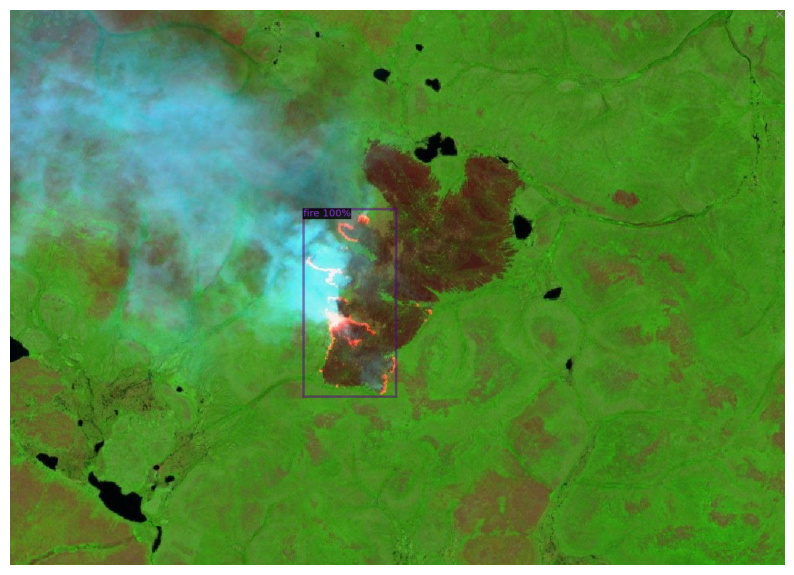

Image: /content/wildfire_satelite-4/test/cl6lsxiqd001v8w55fgtjavib_2_FALSE_COLOR_jpg.rf.1f8d13fdf579b920ac8e7d772e014f31.jpg
Scores: [0.9956312 0.9754043 0.9412823 0.925353  0.767689  0.631251 ]


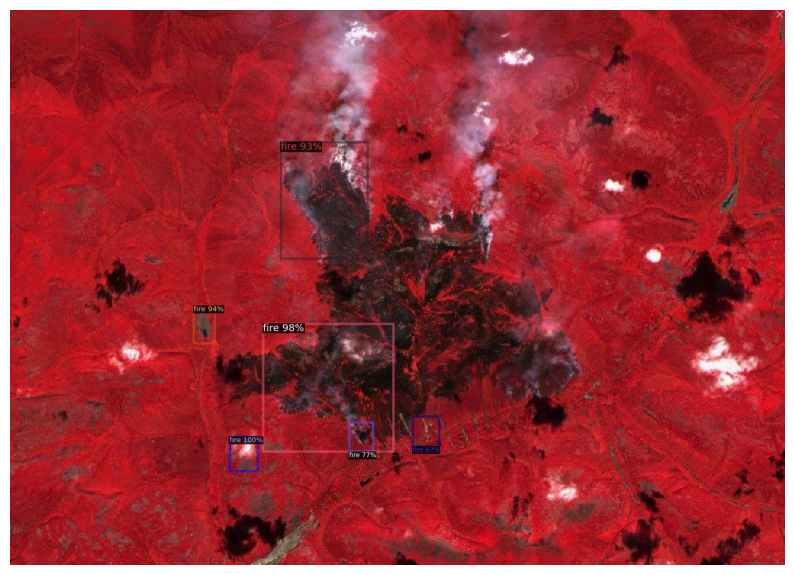

In [ ]:
dataset_dicts = DatasetCatalog.get("forest_fire_test")

for d in random.sample(dataset_dicts, 3):
    img = cv2.imread(d["file_name"])
    outputs = predictor(img)

    v = Visualizer(img[:, :, ::-1], metadata=forest_metadata, scale=1.2)
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

    scores = outputs["instances"].scores.cpu().numpy() if len(outputs["instances"]) else []
    print("Image:", d["file_name"])
    print("Scores:", scores)

    plt.figure(figsize=(10,8))
    plt.imshow(out.get_image())
    plt.axis("off")
    plt.show()
